## Naomi's Notebook

In [18]:
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf

In [3]:
data = pd.read_csv('ai_jobs_market_2025_2026.csv')
data

,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,...,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,AIJOB1496,Multimodal AI Engineer,AI Engineering,Lead (10+ yrs),8,Master's,262000.0,160000,300000,Toronto,...,8.8,90,23.6,7.5,2026,1,1,1,0,Senior ($200-300k)
1496,AIJOB1497,NLP Engineer,AI Engineering,Senior (6-9 yrs),9,Bootcamp/Self-taught,163000.0,145000,290000,Berlin,...,6.7,91,66.5,7.8,2025,3,1,0,0,Upper-Mid ($150-200k)
1497,AIJOB1498,AI Compliance Manager,Governance,Mid (3-5 yrs),10,Master's,127000.0,100000,200000,Zurich,...,10.9,68,15.3,8.3,2026,3,0,1,0,Mid ($100-150k)
1498,AIJOB1499,NLP Engineer,AI Engineering,Lead (10+ yrs),4,Bachelor's,145000.0,145000,290000,Bangalore,...,8.5,91,78.8,7.4,2025,5,1,1,0,Mid ($100-150k)


In [8]:
data['annual_salary_usd'].min(), data['annual_salary_usd'].max()

(np.float64(90000.0), np.float64(384000.0))

<Axes: xlabel='annual_salary_usd', ylabel='Count'>

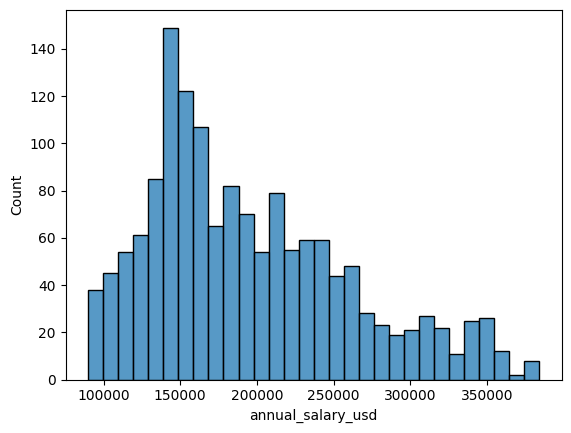

In [11]:
sns.histplot(data['annual_salary_usd'], bins=30)

<Axes: xlabel='years_of_experience', ylabel='annual_salary_usd'>

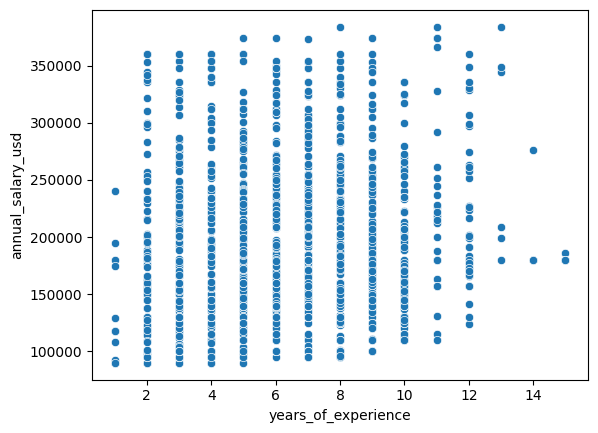

In [13]:
sns.scatterplot(data = data, x = 'years_of_experience', y = 'annual_salary_usd')

In [4]:
data.columns


Index(['job_id', 'job_title', 'job_category', 'experience_level',
       'years_of_experience', 'education_required', 'annual_salary_usd',
       'salary_min_usd', 'salary_max_usd', 'city', 'country', 'remote_work',
       'company_size', 'industry', 'required_skills', 'ai_salary_premium_pct',
       'demand_score', 'demand_growth_yoy_pct', 'benefits_score_10',
       'posting_year', 'posting_month', 'is_senior', 'is_remote_friendly',
       'is_llm_role', 'salary_tier'],
      dtype='str')

## Which variables to use
We will narrow down the variables to use in our analysis first by addressing multicollinearity to remove variables that are correlated with each other. 

Create a model with all variables

In [54]:
all_model = smf.ols(data = data, formula = 'annual_salary_usd ~ experience_level + years_of_experience + education_required + city + country + remote_work + company_size + ai_salary_premium_pct + demand_score + demand_growth_yoy_pct + benefits_score_10 + posting_year + posting_month + is_senior + is_remote_friendly + is_llm_role').fit()
print(all_model.summary())

                            OLS Regression Results                            
Dep. Variable:      annual_salary_usd   R-squared:                       0.743
Model:                            OLS   Adj. R-squared:                  0.736
Method:                 Least Squares   F-statistic:                     105.6
Date:                Fri, 15 May 2026   Prob (F-statistic):               0.00
Time:                        18:16:25   Log-Likelihood:                -17766.
No. Observations:                1500   AIC:                         3.561e+04
Df Residuals:                    1459   BIC:                         3.583e+04
Df Model:                          40                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

Check for multicolinearity of variables using VIF

In [55]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

exog = all_model.model.exog
names = all_model.params.index
for i in range(1, exog.shape[1]):
    print(f'VIF: {names[i]}: {variance_inflation_factor(exog, i): .3f}')

c:\Users\nkort\anaconda3\envs\MATH189env\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


VIF: experience_level[T.Lead (10+ yrs)]:  inf
VIF: experience_level[T.Mid (3-5 yrs)]:  1.527
VIF: experience_level[T.Senior (6-9 yrs)]:  inf
VIF: education_required[T.Bachelor's]:  1.657
VIF: education_required[T.Bootcamp/Self-taught]:  1.636
VIF: education_required[T.Master's]:  1.676
VIF: education_required[T.PhD]:  1.608
VIF: city[T.Austin]:  inf
VIF: city[T.Bangalore]:  inf
VIF: city[T.Beijing]:  inf
VIF: city[T.Berlin]:  inf
VIF: city[T.Boston]:  inf
VIF: city[T.Chicago]:  inf
VIF: city[T.Dubai]:  inf
VIF: city[T.London]:  inf
VIF: city[T.Los Angeles]:  inf
VIF: city[T.New York]:  inf
VIF: city[T.Paris]:  inf
VIF: city[T.Remote]:  inf
VIF: city[T.San Francisco]:  inf
VIF: city[T.Seattle]:  inf
VIF: city[T.Singapore]:  inf
VIF: city[T.Sydney]:  inf
VIF: city[T.Tokyo]:  inf
VIF: city[T.Toronto]:  inf
VIF: city[T.Zurich]:  inf
VIF: country[T.Canada]:  inf
VIF: country[T.China]:  inf
VIF: country[T.France]:  inf
VIF: country[T.Germany]:  inf
VIF: country[T.Global]:  inf
VIF: country[T

experience_level, city, country, remote_work, is_senior, and is_remote_friendly have VIFs of infinity. 
For our analysis we will only include one of 
- experience_level, years_of_experience, or is_senior (they all encode experience level)
- remote_friendly or remote_work (they both encode remote work)
- city or country (city is correlated with the country it is located in)
in a linear model. 

Checking VIF with only one variables from each correlated group



In [57]:
#removed is_senior and experience_level (kept years_of_experience)
#removed is_remote_friendly
#removed country

uncorrelated_model = smf.ols(data = data, formula = 'annual_salary_usd ~ years_of_experience + education_required + city + remote_work + company_size + ai_salary_premium_pct + demand_score + demand_growth_yoy_pct + benefits_score_10 + posting_year + posting_month + is_llm_role').fit()



exog = uncorrelated_model.model.exog
names = uncorrelated_model.params.index
for i in range(1, exog.shape[1]):
    print(f'VIF: {names[i]}: {variance_inflation_factor(exog, i): .3f}')

VIF: education_required[T.Bachelor's]:  1.653
VIF: education_required[T.Bootcamp/Self-taught]:  1.632
VIF: education_required[T.Master's]:  1.666
VIF: education_required[T.PhD]:  1.605
VIF: city[T.Austin]:  1.956
VIF: city[T.Bangalore]:  1.726
VIF: city[T.Beijing]:  2.059
VIF: city[T.Berlin]:  2.004
VIF: city[T.Boston]:  1.864
VIF: city[T.Chicago]:  1.961
VIF: city[T.Dubai]:  1.769
VIF: city[T.London]:  2.106
VIF: city[T.Los Angeles]:  1.787
VIF: city[T.New York]:  1.845
VIF: city[T.Paris]:  1.826
VIF: city[T.Remote]:  2.006
VIF: city[T.San Francisco]:  2.130
VIF: city[T.Seattle]:  1.864
VIF: city[T.Singapore]:  1.884
VIF: city[T.Sydney]:  1.957
VIF: city[T.Tokyo]:  1.947
VIF: city[T.Toronto]:  2.046
VIF: city[T.Zurich]:  1.950
VIF: remote_work[T.Hybrid]:  1.427
VIF: remote_work[T.On-site]:  1.415
VIF: company_size[T.Enterprise (5000+)]:  1.636
VIF: company_size[T.Mid-size (501-5000)]:  1.646
VIF: company_size[T.SME (51-500)]:  1.621
VIF: company_size[T.Startup (1-50)]:  1.649
VIF: yea

With the correlated variables removed, none of the VIFs of the remaining variables are high. 

In [48]:
#variables with significant pvalues

significant_vars = ['experience_level', 'education_required', 'company_size', 'years_of_experience', 'ai_salary_premium_pct', 'demand_score', 'demand_growth_yoy_pct', 'is_senior', 'is_llm_role']
significant_model = smf.ols(data = data, formula = 'annual_salary_usd ~ experience_level + education_required + company_size + years_of_experience + ai_salary_premium_pct + demand_score + demand_growth_yoy_pct + is_senior + is_llm_role').fit()
print(significant_model.summary())

                            OLS Regression Results                            
Dep. Variable:      annual_salary_usd   R-squared:                       0.537
Model:                            OLS   Adj. R-squared:                  0.532
Method:                 Least Squares   F-statistic:                     107.3
Date:                Thu, 14 May 2026   Prob (F-statistic):          6.54e-234
Time:                        17:31:53   Log-Likelihood:                -18209.
No. Observations:                1500   AIC:                         3.645e+04
Df Residuals:                    1483   BIC:                         3.654e+04
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------

Check assumptions for each of the significant variables
- see if there are any interesting insights from model violations